# 04 — Example PSF cutouts by quality tier

Produces `fig/tier_gallery.pdf` (`fig:gallery`): example $i$-band raft-stacked PSF
stamps drawn from each shapelet-score tier, with the shapelet reconstruction and the
residual, annotated with both scores and the FWHM.

This is the visual justification for the tier boundaries: the reader should be able to
see the coma/trefoil appear as the score rises.

Requires reading individual stamp files, which are slow on this filesystem
(~0.5-1 s each), so we search a bounded number of candidates per tier.

In [1]:
import importlib.util
spec = importlib.util.spec_from_file_location('plot_config', 'plot_config.py')
plot_config = importlib.util.module_from_spec(spec); spec.loader.exec_module(plot_config)
from plot_config import (BMAX, ODD_ORDER, FIG, DATA, STAMPS_DIR, TIERS, TIER_COLORS,
                         PALETTE, apply_style, bvec_path, shapelet_score, moment_score,
                         FWHM_PER_SIGMA, SCIENCE_RAFTS)

import numpy as np
import pandas as pd
import galsim
import matplotlib.pyplot as plt

apply_style()
TAG = 'dp2all'      # DP2 has the matched per-raft moment catalog
BAND = 'i'
N_SHOW = 4          # examples per tier
rng = np.random.default_rng(7)

In [2]:
d = np.load(bvec_path(BAND, TAG))
score = shapelet_score(d['bvec'])
lib = pd.DataFrame(dict(idx=np.arange(len(score)), visit=d['visit'],
                        detector=d['detector'], score=score,
                        fwhm=d['sigma'] * FWHM_PER_SIGMA))
print(f'{len(lib):,} {BAND}-band PSFs in {TAG}')

# Attach the moment score for the same (visit, raft) from the DP2 moment catalog.
mom = pd.read_parquet(DATA / 'psf_moments_allbands.pq',
                      columns=['visit_id'] +
                      [f'{c}_{r}' for r in SCIENCE_RAFTS
                       for c in ('c11', 'c12', 'c31', 'c32')])
long = []
for r in SCIENCE_RAFTS:
    sub = mom[['visit_id', f'c11_{r}', f'c12_{r}', f'c31_{r}', f'c32_{r}']].copy()
    sub.columns = ['visit_id', 'c11', 'c12', 'c31', 'c32']
    sub['raft'] = r
    long.append(sub)
long = pd.concat(long, ignore_index=True).dropna()
long['mscore'] = moment_score(long.c11, long.c12, long.c31, long.c32)
print(f'{len(long):,} (visit, raft) moment rows')

164,443 i-band PSFs in dp2all
607,959 (visit, raft) moment rows


In [3]:
MIN_STACK = 40      # require a deep enough stack that the stamp is not noise-dominated
NEIGHBOUR_FRAC = 0.06   # reject stamps with a bright neighbour in the outskirts


def fetch(row):
    """Load the stacked stamp for one library row.

    Returns (stamp, raft, n_stack) or None if the file is missing, the detector
    is absent, the stack is too shallow, or a neighbouring source contaminates
    the outskirts of the stamp.
    """
    f = STAMPS_DIR / f"stamps_{int(row.visit)}.npz"
    if not f.exists():
        return None
    z = np.load(f, allow_pickle=True)
    m = z['detector'] == int(row.detector)
    if not m.any():
        return None
    j = int(np.where(m)[0][0])
    n_stack = int(z['n_stack'][j])
    if n_stack < MIN_STACK:
        return None
    stamp = z['stamps'][j].astype(np.float64)

    # Reject blends: nothing in the outer annulus should be a sizeable fraction
    # of the peak. The PSF itself is confined to the central ~20 pixels.
    h = stamp.shape[0] // 2
    outer = stamp.copy()
    outer[h - 10:h + 11, h - 10:h + 11] = 0.0
    if outer.max() > NEIGHBOUR_FRAC * stamp.max():
        return None
    return stamp, str(z['raft'][j]), n_stack


def model_and_residual(stamp, idx):
    """Shapelet reconstruction of library entry idx, drawn on the stamp grid."""
    shp = galsim.Shapelet(float(d['sigma'][idx]), BMAX, d['bvec'][idx])
    img = galsim.Image(stamp.shape[0], stamp.shape[1], scale=0.2)
    shp.drawImage(image=img, method='sb')
    return img.array, stamp - img.array


picks = {}
for name, lo, hi, _ in TIERS:
    m = np.ones(len(lib), bool)
    if lo is not None: m &= lib.score.values >= lo
    if hi is not None: m &= lib.score.values < hi
    cand = lib[m]
    cand = cand.sample(n=min(150, len(cand)), random_state=7)
    got, tried = [], 0
    for row in cand.itertuples():
        if len(got) >= N_SHOW:
            break
        tried += 1
        r = fetch(row)
        if r is None:
            continue
        stamp, raft, n_stack = r
        mm = long[(long.visit_id == row.visit) & (long.raft == raft)]
        got.append(dict(stamp=stamp, raft=raft, visit=int(row.visit), idx=int(row.idx),
                        score=row.score, fwhm=row.fwhm, n_stack=n_stack,
                        mscore=float(mm.mscore.iloc[0]) if len(mm) else np.nan))
    picks[name] = got
    print(f'{name:>10}: {len(got)} stamps kept from {tried} tried  '
          f'(score range {cand.score.min():.5f}-{cand.score.max():.5f}, '
          f'n_stack {[p["n_stack"] for p in got]})')

       LOW: 4 stamps kept from 6 tried  (score range 0.00001-0.00200, n_stack [100, 100, 94, 100])
    MEDIUM: 4 stamps kept from 4 tried  (score range 0.00200-0.00500, n_stack [100, 100, 100, 99])


      HIGH: 4 stamps kept from 6 tried  (score range 0.00501-0.01931, n_stack [100, 100, 100, 100])


 VERY HIGH: 4 stamps kept from 12 tried  (score range 0.02028-0.07730, n_stack [100, 97, 100, 88])


wrote /sdf/data/rubin/user/ztq1996/psf-rubin/psf_zernike/shapelet_score_paper/fig/tier_gallery.pdf


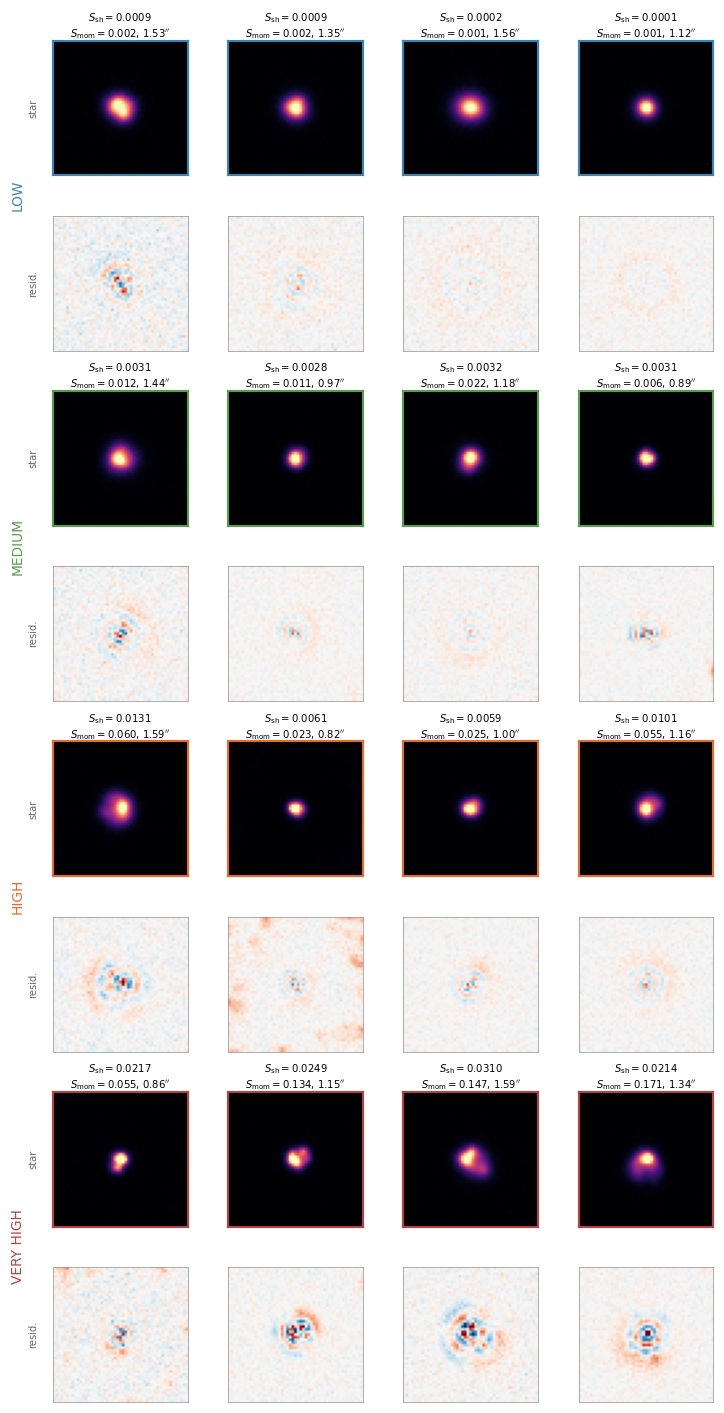

In [4]:
TIER_NAMES = [t[0] for t in TIERS]
ncol = N_SHOW
nrow = len(TIER_NAMES) * 2          # star row + residual row per tier

fig, axes = plt.subplots(nrow, ncol, figsize=(1.55 * ncol + 0.9, 1.62 * nrow))
fig.subplots_adjust(left=0.11, right=0.995, top=0.965, bottom=0.01,
                    wspace=0.06, hspace=0.30)

for ti, name in enumerate(TIER_NAMES):
    for j in range(ncol):
        ax_s, ax_r = axes[2 * ti, j], axes[2 * ti + 1, j]
        for a in (ax_s, ax_r):
            a.set_xticks([]); a.set_yticks([])
        if j >= len(picks[name]):
            ax_s.axis('off'); ax_r.axis('off'); continue
        p = picks[name][j]
        model, resid = model_and_residual(p['stamp'], p['idx'])
        vmax = np.nanpercentile(p['stamp'], 99.7)
        ax_s.imshow(p['stamp'], origin='lower', cmap='magma', vmin=0, vmax=vmax)
        rv = vmax / 12
        ax_r.imshow(resid, origin='lower', cmap='RdBu_r', vmin=-rv, vmax=rv)
        ax_s.set_title(f"$S_{{\\rm sh}}={p['score']:.4f}$\n"
                       f"$S_{{\\rm mom}}={p['mscore']:.3f}$, "
                       f"{p['fwhm']:.2f}$^{{\\prime\\prime}}$",
                       fontsize=6.6, pad=2.2)
        for a, c in ((ax_s, TIER_COLORS[name]), (ax_r, '0.6')):
            for s in a.spines.values():
                s.set_color(c); s.set_linewidth(1.4 if a is ax_s else 0.5)

    # tier label to the left of the star row
    bb0 = axes[2 * ti, 0].get_position(); bb1 = axes[2 * ti + 1, 0].get_position()
    fig.text(0.085, 0.5 * (bb0.y1 + bb1.y0), name, rotation=90, ha='center',
             va='center', fontsize=9, color=TIER_COLORS[name])
    fig.text(0.105, bb0.y0 + bb0.height / 2, 'star', rotation=90, ha='center',
             va='center', fontsize=6.5, color='0.4')
    fig.text(0.105, bb1.y0 + bb1.height / 2, 'resid.', rotation=90, ha='center',
             va='center', fontsize=6.5, color='0.4')

fig.savefig(FIG / 'tier_gallery.pdf')
print('wrote', FIG / 'tier_gallery.pdf')

In [5]:
# Numbers quoted in the text: score ranges and stacking depth per tier.
# NOTE: the residual power fraction is NOT quoted in the paper -- with only
# N_SHOW examples per tier it is dominated by which particular stamps were drawn.
for name in TIER_NAMES:
    sc = [p['score'] for p in picks[name]]
    ms = [p['mscore'] for p in picks[name]]
    ns = [p['n_stack'] for p in picks[name]]
    fw = [p['fwhm'] for p in picks[name]]
    print(f'{name:>10}: S_sh {np.min(sc):.5f}-{np.max(sc):.5f}   '
          f'S_mom {np.nanmin(ms):.4f}-{np.nanmax(ms):.4f}   '
          f'FWHM {np.min(fw):.2f}-{np.max(fw):.2f}"   n_stack {np.min(ns)}-{np.max(ns)}')

       LOW: S_sh 0.00007-0.00094   S_mom 0.0005-0.0025   FWHM 1.12-1.56"   n_stack 94-100
    MEDIUM: S_sh 0.00276-0.00322   S_mom 0.0064-0.0222   FWHM 0.89-1.44"   n_stack 99-100
      HIGH: S_sh 0.00590-0.01309   S_mom 0.0228-0.0595   FWHM 0.82-1.59"   n_stack 100-100
 VERY HIGH: S_sh 0.02142-0.03099   S_mom 0.0550-0.1713   FWHM 0.86-1.59"   n_stack 88-100
